In [2]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from utils import get_eval_stats
import scipy

In [3]:
target_protein=None
test_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/test/"
valid_dir = "/home/shai/BLISS_Experiments/DRAKES/DRAKES/drakes_protein/fmif/eval_results/validation/"
summary_func = np.mean

In [4]:
#################################

drakes_df = pd.read_csv(test_dir + "drakes_test.csv")#SBATCH --partition=gpu
#SBATCH --gres=gpu:1
#SBATCH --cpus-per-task=1
#SBATCH --mem=16G
#SBATCH --job-name=protein
#SBATCH --output=worker_%j.out

pretrained_df = pd.read_csv(test_dir + "pretrained_test.csv")

drakes_eval_stats = get_eval_stats(drakes_df, target_protein=target_protein, summary_func=summary_func)
pre_eval_stats = get_eval_stats(pretrained_df, target_protein=target_protein, summary_func=summary_func)

drakes_ddg_align = drakes_eval_stats['ddg_align']
pre_ddg_align = pre_eval_stats['ddg_align']

#################################

In [5]:
from pathlib import Path
import glob
import re

base_dir = Path(test_dir)

run_configs = [
    # maxspecorder=20 set
    {
        "method": "Max-mask",
        "cohort": "best-of-n",
        "patterns": [
            "heldout/pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=20_masks=32768_rmax=True.csv"
        ],
    },
    {
        "method": "Max-mask",
        "cohort": "pretrained",
        "patterns": [
            "delta_2/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=20_masks=32768_rmax=False_w*.csv"
        ],
    },
    {
        "method": "Spectral",
        "cohort": "best-of-n",
        "patterns": [
            "heldout/pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=True.csv"
        ],
    },
    {
        "method": "Spectral",
        "cohort": "pretrained",
        "patterns": [
            "new/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=32768_rmax=False_.csv"
        ],
    },

    # maxspecorder=10 set
    {
        "method": "Max-mask",
        "cohort": "best-of-n",
        "patterns": [
            "target/group1/pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=10*.csv"
        ],
    },
    {
        "method": "Max-mask",
        "cohort": "pretrained",
        "patterns": [
            "target/group1/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=max-mask_maxspecorder=10*.csv"
        ],
    },
    {
        "method": "Token exclusion",
        "cohort": "best-of-n",
        "patterns": [
            "target/group1/pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv"
        ],
    },
    {
        "method": "Token exclusion",
        "cohort": "pretrained",
        "patterns": [
            "target/group1/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=exclusion_maxspecorder=10.csv"
        ],
    },
    {
        "method": "Spectral",
        "cohort": "best-of-n",
        "patterns": [
            "target/group1/pretrained_test_ddg_bon_N=10_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192_rmax=True.csv"
        ],
    },
    {
        "method": "Spectral",
        "cohort": "pretrained",
        "patterns": [
            "target/group1/pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=10_masks=8192.csv"
        ],
    },
]


def collect_files(patterns):
    files = []
    for pattern in patterns:
        files.extend(sorted(glob.glob(str(base_dir / pattern))))
    return files


def eval_stats_from_files(files):
    if len(files) == 0:
        return {}, 0
    dfs = [pd.read_csv(f) for f in files]
    merged = pd.concat(dfs, ignore_index=True)
    return get_eval_stats(merged, target_protein=target_protein, summary_func=summary_func), len(merged)


def extract_int_from_name(name, key):
    match = re.search(rf"{key}=(\d+)", name)
    return int(match.group(1)) if match else None


source_rows = []
stats_rows = []
for cfg in run_configs:
    method_name = cfg["method"]
    cohort_name = cfg["cohort"]
    patterns = cfg["patterns"]

    files = collect_files(patterns)
    stats, n_samples = eval_stats_from_files(files)

    n_values = sorted(
        {
            extract_int_from_name(Path(f).name, "bon_N")
            for f in files
            if extract_int_from_name(Path(f).name, "bon_N") is not None
        }
    )
    n_used = n_values[0] if len(n_values) == 1 else (n_values if n_values else None)

    order_values = sorted(
        {
            extract_int_from_name(Path(f).name, "maxspecorder")
            for f in files
            if extract_int_from_name(Path(f).name, "maxspecorder") is not None
        }
    )
    maxspecorder_used = order_values[0] if len(order_values) == 1 else (order_values if order_values else None)

    source_rows.append(
        {
            "method": method_name,
            "cohort": cohort_name,
            "N": n_used,
            "maxspecorder": maxspecorder_used,
            "num_files": len(files),
            "num_samples": n_samples,
            "patterns": patterns,
            "matched_files": [str(Path(f).relative_to(base_dir)) for f in files],
        }
    )

    row = {
        "method": method_name,
        "cohort": cohort_name,
        "N": n_used,
        "maxspecorder": maxspecorder_used,
        "num_files": len(files),
        "num_samples": n_samples,
    }
    row.update(stats)
    stats_rows.append(row)

source_df = pd.DataFrame(source_rows)
comparison_df = pd.DataFrame(stats_rows)

metric_cols = [
    c
    for c in [
        "ddg",
        "ddg_std",
        "ddg_align",
        "ddg_align_std",
        "pos_ddg_prop",
        "scrmsd",
        "scrmsd_std",
        "low_scrmsd_prop",
        "success_rate",
        "ll",
        "ll_std",
    ]
    if c in comparison_df.columns
]

# Useful to verify where maxspecorder=20 is used for each method/cohort.
print("Matched CSV sources:")
display(source_df[["method", "cohort", "N", "maxspecorder", "num_files", "num_samples", "matched_files"]])

print("\nEval stats comparison:")
display(comparison_df[["method", "cohort", "N", "maxspecorder", "num_files", "num_samples"] + metric_cols].sort_values(["maxspecorder", "cohort", "method"]))

if (comparison_df["maxspecorder"] != 20).any():
    print("\nNote: not all methods have maxspecorder=20 in available eval CSVs (token exclusion is maxspecorder=10).")

Matched CSV sources:


,method,cohort,N,maxspecorder,num_files,num_samples,matched_files
0,Max-mask,best-of-n,10.0,20.0,1,180,[heldout/pretrained_test_ddg_bon_N=10_feedback...
1,Max-mask,pretrained,1.0,20.0,12,180,[delta_2/pretrained_test_ddg_bon_N=1_feedbacks...
2,Spectral,best-of-n,10.0,20.0,1,180,[heldout/pretrained_test_ddg_bon_N=10_feedback...
3,Spectral,pretrained,1.0,20.0,1,180,[new/pretrained_test_ddg_bon_N=1_feedbacksteps...
4,Max-mask,best-of-n,NaN,NaN,0,0,[]
5,Max-mask,pretrained,NaN,NaN,0,0,[]
6,Token exclusion,best-of-n,10.0,10.0,1,180,[target/group1/pretrained_test_ddg_bon_N=10_fe...
7,Token exclusion,pretrained,1.0,10.0,1,180,[target/group1/pretrained_test_ddg_bon_N=1_fee...
8,Spectral,best-of-n,10.0,10.0,1,180,[target/group1/pretrained_test_ddg_bon_N=10_fe...
9,Spectral,pretrained,1.0,10.0,1,180,[target/group1/pretrained_test_ddg_bon_N=1_fee...



Eval stats comparison:


,method,cohort,N,maxspecorder,num_files,num_samples,ddg,ddg_std,ddg_align,ddg_align_std,pos_ddg_prop,scrmsd,scrmsd_std,low_scrmsd_prop,success_rate,ll,ll_std
8,Spectral,best-of-n,10.0,10.0,1,180,0.708283,1.152116,0.652282,0.134202,0.777778,1.074968,0.774390,0.905556,0.688889,-147.242054,41.558562
6,Token exclusion,best-of-n,10.0,10.0,1,180,0.429178,1.194429,0.583880,0.162725,0.705556,1.135145,0.878254,0.900000,0.627778,-146.039353,41.573538
9,Spectral,pretrained,1.0,10.0,1,180,0.247570,1.233894,0.503219,0.209086,0.616667,1.116052,0.956606,0.900000,0.572222,-146.508215,42.861957
7,Token exclusion,pretrained,1.0,10.0,1,180,0.095487,1.270863,0.375926,0.279839,0.550000,1.198768,1.391061,0.927778,0.527778,-146.185671,43.070079
0,Max-mask,best-of-n,10.0,20.0,1,180,0.742543,1.116612,0.680094,0.115424,0.805556,NaN,NaN,NaN,NaN,-147.326657,41.391925
2,Spectral,best-of-n,10.0,20.0,1,180,0.766127,1.087715,0.682888,0.112752,0.794444,NaN,NaN,NaN,NaN,-147.137831,41.327660
1,Max-mask,pretrained,1.0,20.0,12,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Spectral,pretrained,1.0,20.0,1,180,0.412154,1.182973,0.545331,0.196103,0.677778,NaN,NaN,NaN,NaN,-146.781681,43.180457
4,Max-mask,best-of-n,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Max-mask,pretrained,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Note: not all methods have maxspecorder=20 in available eval CSVs (token exclusion is maxspecorder=10).


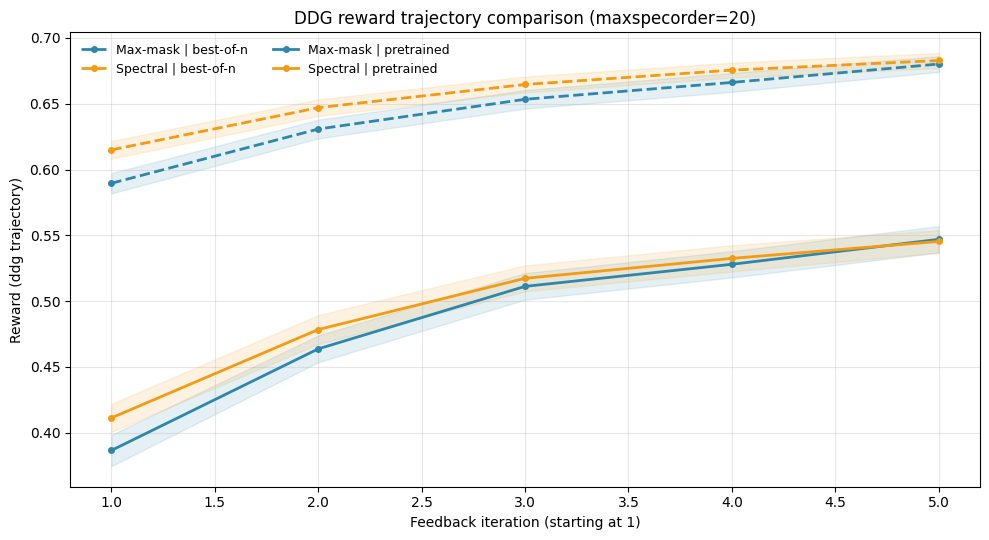

In [6]:
import ast

# Per-iteration reward trajectory in these eval CSVs (same as prior traj comps).
traj_col = "spec_trajectory"


def _parse_traj(x):
    if isinstance(x, list):
        return np.array(x, dtype=float)
    if pd.isna(x):
        return None
    x = str(x).strip()
    if x == "" or x == "[]":
        return None
    try:
        return np.array(ast.literal_eval(x), dtype=float)
    except Exception:
        return None


def calc_avg_traj(df, traj_col, target_protein=None):
    if target_protein is not None:
        df = df[df["protein_name"] == target_protein + ".pdb"]

    protein_names = sorted(set(df["protein_name"]))

    cluster_means = []
    for p in protein_names:
        df_p = df[df["protein_name"] == p]
        traj_p = np.array([eval(lst) for lst in df_p[traj_col].tolist()])
        cluster_means.append(np.mean(traj_p, axis=0))

    avg_traj = np.mean(cluster_means, axis=0)

    # Standard error calculations (exactly as in neurips_figures1.ipynb)
    std_errors = []
    for p in protein_names:
        df_p = df[df["protein_name"] == p]
        traj_p = np.array([eval(lst) for lst in df_p[traj_col].tolist()])
        std_err = scipy.stats.sem(traj_p, axis=0)
        std_errors.append(std_err)

    n_proteins = len(protein_names)
    std_errors = np.array(std_errors)
    std_err = np.sqrt(np.sum(std_errors ** 2, axis=0)) / n_proteins

    return avg_traj, std_err


# Build one merged dataframe per (method, cohort, maxspecorder).
traj_groups = {}
for cfg in run_configs:
    method = cfg["method"]
    cohort = cfg["cohort"]
    files = collect_files(cfg["patterns"])
    if len(files) == 0:
        continue

    dfs = [pd.read_csv(f) for f in files]
    merged = pd.concat(dfs, ignore_index=True)

    order_vals = sorted(
        {
            extract_int_from_name(Path(f).name, "maxspecorder")
            for f in files
            if extract_int_from_name(Path(f).name, "maxspecorder") is not None
        }
    )
    if len(order_vals) == 0:
        continue

    # For this notebook each cfg maps to a single order, keep first for keying.
    order = order_vals[0]
    traj_groups[(method, cohort, order)] = merged


# Plot everything on one graph, restricted to maxspecorder=20.
def plot_all_trajs_single_ax(ax, target_order=20):
    method_colors = {
        "Max-mask": "#2E86AB",
        "Token exclusion": "#7D3C98",
        "Spectral": "#F39C12",
    }
    cohort_linestyle = {
        "pretrained": "-",
        "best-of-n": "--",
    }

    plotted_any = False
    for method, cohort, order in sorted(traj_groups.keys(), key=lambda x: (x[1], x[0])):
        if order != target_order:
            continue

        df = traj_groups[(method, cohort, order)]
        avg_traj, err = calc_avg_traj(df, traj_col=traj_col, target_protein=target_protein)
        if avg_traj is None:
            continue

        # Show only feedback iterations (exclude iteration 0).
        iters = np.arange(1, avg_traj.shape[0])
        if iters.size == 0:
            continue
        traj = avg_traj[1:]
        traj_err = err[1:]

        color = method_colors.get(method, None)
        linestyle = cohort_linestyle.get(cohort, "-")
        label = f"{method} | {cohort}"

        ax.plot(
            iters,
            traj,
            label=label,
            color=color,
            linestyle=linestyle,
            marker="o",
            linewidth=2,
            markersize=4,
        )
        ax.fill_between(iters, traj - traj_err, traj + traj_err, color=color, alpha=0.12)
        plotted_any = True

    ax.set_title(f"DDG reward trajectory comparison (maxspecorder={target_order})")
    ax.set_xlabel("Feedback iteration (starting at 1)")
    ax.set_ylabel("Reward (ddg trajectory)")
    ax.grid(alpha=0.3)

    if plotted_any:
        ax.legend(frameon=False, fontsize=9, ncol=2)
    else:
        ax.text(0.5, 0.5, f"No matching maxspecorder={target_order} runs", ha="center", va="center", transform=ax.transAxes)


fig, ax = plt.subplots(figsize=(10, 5.5))
plot_all_trajs_single_ax(ax, target_order=20)
plt.tight_layout()
plt.show()

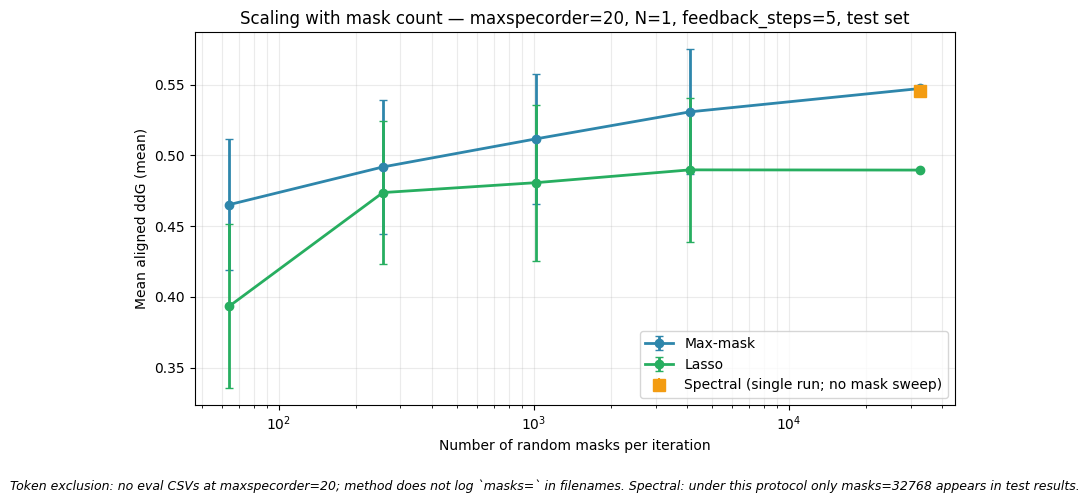

,method,mask,mean_ddg_align,se,n_files,path
0,Max-mask,64,0.465170,0.046170,7,NaN
1,Max-mask,256,0.491804,0.047600,13,NaN
2,Max-mask,1024,0.511721,0.046056,13,NaN
3,Max-mask,4096,0.530772,0.044238,13,NaN
4,Max-mask,32768,0.547289,0.000000,1,NaN
5,Lasso,64,0.393381,0.057914,13,NaN
6,Lasso,256,0.473681,0.050290,13,NaN
7,Lasso,1024,0.480717,0.055217,13,NaN
8,Lasso,4096,0.489749,0.050881,13,NaN
9,Lasso,32768,0.489596,0.000000,1,NaN


In [8]:
# Mask scaling at maxspecorder=20 (20 edit positions per spectral / max-mask / lasso iteration).
# Protocol: pretrained *test* split, best-of-1 (N=1), feedback_steps=5, rmax=False.
# Per mask count: mean `ddg` (aligned oracle) over CSVs matching that mask (including w* worker seeds); error bars = SE across those CSV means.
#
# Data availability:
# - Max-mask & Lasso: full sweeps over masks in test/eval_results.
# - Spectral: only a single N=1, fs=5, rmax=False run on disk at masks=32768 (no mask sweep under this protocol).
# - Token exclusion: no `maxspecorder=20` eval CSVs in the repo (exclusion uses exhaustive token scores; filenames omit `masks=`).

from pathlib import Path
import glob
import re

base = Path(test_dir)

method_colors = {
    "Max-mask": "#2E86AB",
    "Spectral": "#F39C12",
    "Lasso": "#27AE60",
    "Token exclusion": "#7D3C98",
}


def extract_masks(name: str):
    m = re.search(r"masks=(\d+)", name)
    return int(m.group(1)) if m else None


def aggregate_mask_curve(feedback_method: str, *, lasso_lambda=None):
    """Returns sorted list of dicts: mask, mean_ddg_align, se, n_files.

    lasso_lambda: if set, only keep basenames containing f\"lassolambda={lasso_lambda}\".
    """
    pattern = str(
        base
        / "**"
        / f"pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod={feedback_method}_maxspecorder=20_masks=*_rmax=False*.csv"
    )
    files = glob.glob(pattern, recursive=True)
    if lasso_lambda is not None:
        files = [f for f in files if f"lassolambda={lasso_lambda}" in Path(f).name]
    by_mask: dict[int, list[str]] = {}
    for f in files:
        mk = extract_masks(Path(f).name)
        if mk is None:
            continue
        cols = pd.read_csv(f, nrows=0).columns
        if "ddg" not in cols:
            continue  # incomplete worker output (trajectory-only CSV)
        by_mask.setdefault(mk, []).append(f)
    rows = []
    for mk in sorted(by_mask):
        per_file_means = []
        for f in sorted(by_mask[mk]):
            df = pd.read_csv(f)
            st = get_eval_stats(df, target_protein=target_protein, summary_func=summary_func)
            per_file_means.append(st["ddg_align"])
        per_file_means = np.asarray(per_file_means, dtype=float)
        rows.append(
            {
                "mask": mk,
                "mean_ddg_align": float(np.mean(per_file_means)),
                "se": float(per_file_means.std(ddof=1) / np.sqrt(len(per_file_means)))
                if len(per_file_means) > 1
                else 0.0,
                "n_files": len(per_file_means),
            }
        )
    return rows


def spectral_fs5_single():
    hits = glob.glob(
        str(
            base
            / "**"
            / "pretrained_test_ddg_bon_N=1_feedbacksteps=5_feedbackmethod=spectral_maxspecorder=20_masks=*_rmax=False*.csv"
        ),
        recursive=True,
    )
    out = []
    for f in hits:
        mk = extract_masks(Path(f).name)
        if mk is None:
            continue
        cols = pd.read_csv(f, nrows=0).columns
        if "ddg" not in cols:
            continue
        df = pd.read_csv(f)
        st = get_eval_stats(df, target_protein=target_protein, summary_func=summary_func)
        out.append({"path": f, "mask": mk, **st})
    return out


fig, ax = plt.subplots(figsize=(8.5, 5.0))

for method, rows in [
    ("Max-mask", aggregate_mask_curve("max-mask")),
    ("Lasso", aggregate_mask_curve("lasso", lasso_lambda="0.0001")),
]:
    if not rows:
        continue
    xs = [r["mask"] for r in rows]
    ys = [r["mean_ddg_align"] for r in rows]
    es = [max(r["se"], 1e-6) for r in rows]
    ax.errorbar(
        xs,
        ys,
        yerr=es,
        marker="o",
        capsize=3,
        label=method,
        color=method_colors[method],
        linewidth=2,
    )

sp_rows = spectral_fs5_single()
if sp_rows:
    for i, r in enumerate(sp_rows):
        ax.errorbar(
            [r["mask"]],
            [r["ddg_align"]],
            yerr=0,
            marker="s",
            markersize=8,
            linestyle="none",
            label="Spectral (single run; no mask sweep)" if i == 0 else None,
            color=method_colors["Spectral"],
        )
else:
    print("No spectral N=1 fs=5 rmax=False maxspecorder=20 CSVs found.")

ax.set_xscale("log", base=10)
ax.set_xlabel("Number of random masks per iteration")
ax.set_ylabel(f"Mean aligned ddG ({summary_func.__name__})")
ax.set_title("Scaling with mask count — maxspecorder=20, N=1, feedback_steps=5, test set")
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="lower right")

note = (
    "Token exclusion: no eval CSVs at maxspecorder=20; method does not log `masks=` in filenames. "
    "Spectral: under this protocol only masks=32768 appears in test results."
)
fig.text(0.5, 0.01, note, ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

# Tabular summary for the paper / inspection
tbl = []
for method, rows in [
    ("Max-mask", aggregate_mask_curve("max-mask")),
    ("Lasso", aggregate_mask_curve("lasso", lasso_lambda="0.0001")),
]:
    for r in rows:
        tbl.append({"method": method, **r})
for r in sp_rows:
    tbl.append(
        {
            "method": "Spectral",
            "mask": r["mask"],
            "mean_ddg_align": r["ddg_align"],
            "se": 0.0,
            "n_files": 1,
            "path": Path(r["path"]).name,
        }
    )
display(pd.DataFrame(tbl))